<a href="https://colab.research.google.com/github/Chandana-dharshanam/ecg-detection/blob/main/ECG_Arrhythmia_Detection_v2_(drive).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECG Arrhythmia Detection — MIT-BIH

**Goal:** given *any* ECG record, automatically detect every heartbeat and classify it as **Normal** or one of the **Abnormal** types (S / V / F), so it could realistically sit behind a Holter monitor or wearable.

**What's new vs. v1** (fixes the near-zero S/F recall from the first attempt):
1. **RR-interval features** — the model now sees beat *timing* (previous RR, next RR, local RR ratio), not just beat *shape*. This is what actually separates S-class beats from Normal.
2. **Oversampling of minority classes** — S/F/Q beats are duplicated with small jitter/noise so the model sees them as often as N during training, instead of relying on loss-weighting alone.
3. **Focal loss** — focuses training on hard/rare examples instead of the easy majority class.
4. **A single ready-to-use function**: `predict_record(record_name)` — point it at any MIT-BIH record (or your own similarly-formatted signal) and get back detected beats, per-beat Normal/Abnormal classification, a plot, and summary stats. This is the practical deliverable.

Run cells top to bottom.

In [1]:
# 1. Install dependencies (Colab)
!pip install -q wfdb tensorflow scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.3 MB/s eta 0:00:00


In [16]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
import os

ZIP_PATH = "/content/drive/MyDrive/ecg_detection/mit-bih-arrhythmia-database-1.0.0.zip"

print("ZIP exists:", os.path.exists(ZIP_PATH))

if os.path.exists(ZIP_PATH):
    print("ZIP size:", round(os.path.getsize(ZIP_PATH) / (1024 * 1024), 2), "MB")

ZIP exists: True
ZIP size: 73.46 MB


In [18]:
# ============================================================
# STEP 2: LOAD MIT-BIH ARRHYTHMIA DATABASE FROM GOOGLE DRIVE
# ============================================================

import os
import zipfile
import shutil
import glob
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt
from collections import Counter


# ------------------------------------------------------------
# 1. Google Drive ZIP file
# ------------------------------------------------------------

ZIP_PATH = "/content/drive/MyDrive/ecg_detection/mit-bih-arrhythmia-database-1.0.0.zip"

# Temporary location inside Colab
DATA_DIR = "/content/mitdb"


# ------------------------------------------------------------
# 2. Check ZIP file
# ------------------------------------------------------------

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(
        f"Dataset ZIP not found:\n{ZIP_PATH}"
    )

print("Dataset ZIP found!")
print("ZIP size:",
      round(os.path.getsize(ZIP_PATH) / (1024 * 1024), 2),
      "MB")


# ------------------------------------------------------------
# 3. Extract ZIP only if necessary
# ------------------------------------------------------------

if not os.path.exists(DATA_DIR):

    print("\nExtracting MIT-BIH dataset...")
    print("Please wait...")

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall("/content/")

    print("Extraction completed!")


else:
    print("\nMIT-BIH dataset already extracted.")


# ------------------------------------------------------------
# 4. Find the actual MIT-BIH dataset directory
# ------------------------------------------------------------

# Check whether records are directly inside /content/mitdb
if os.path.exists(DATA_DIR):
    possible_files = glob.glob(os.path.join(DATA_DIR, "*.hea"))
else:
    possible_files = []


# If ZIP created a different folder, locate record 100
if not possible_files:

    print("\nSearching extracted files...")

    matches = glob.glob(
        "/content/**/100.hea",
        recursive=True
    )

    if len(matches) > 0:
        DATA_DIR = os.path.dirname(matches[0])


# ------------------------------------------------------------
# 5. Verify dataset
# ------------------------------------------------------------

print("\nDataset directory:")
print(DATA_DIR)

header_files = glob.glob(
    os.path.join(DATA_DIR, "*.hea")
)

print("\nNumber of header files found:", len(header_files))


# ------------------------------------------------------------
# 6. Check important MIT-BIH records
# ------------------------------------------------------------

required_records = ["100", "101", "102", "103", "104"]

print("\nChecking sample records:")

for rec in required_records:

    hea = os.path.join(DATA_DIR, rec + ".hea")
    dat = os.path.join(DATA_DIR, rec + ".dat")
    atr = os.path.join(DATA_DIR, rec + ".atr")

    print(
        rec,
        "->",
        "HEA:", os.path.exists(hea),
        "| DAT:", os.path.exists(dat),
        "| ATR:", os.path.exists(atr)
    )


# ------------------------------------------------------------
# 7. Test WFDB loading
# ------------------------------------------------------------

print("\nTesting WFDB...")

test_record = os.path.join(DATA_DIR, "100")

record = wfdb.rdrecord(test_record)
annotation = wfdb.rdann(test_record, "atr")

print("Record loaded successfully!")

print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs)
print("Number of annotations:", len(annotation.sample))

print("\nDataset is ready for processing!")

Dataset ZIP found!
ZIP size: 73.46 MB

MIT-BIH dataset already extracted.

Dataset directory:
/content/mitdb

Number of header files found: 48

Checking sample records:
100 -> HEA: True | DAT: True | ATR: True
101 -> HEA: True | DAT: True | ATR: True
102 -> HEA: True | DAT: True | ATR: True
103 -> HEA: True | DAT: True | ATR: True
104 -> HEA: True | DAT: True | ATR: True

Testing WFDB...
Record loaded successfully!
Signal shape: (650000, 2)
Sampling frequency: 360
Number of annotations: 2274

Dataset is ready for processing!


In [19]:
# ============================================================
# VERIFY ALL 48 MIT-BIH RECORDS
# ============================================================

import os

print("Checking all MIT-BIH records...\n")

available_records = []

for rec in RECORD_NAMES:
    hea = os.path.join(DATA_DIR, rec + ".hea")
    dat = os.path.join(DATA_DIR, rec + ".dat")
    atr = os.path.join(DATA_DIR, rec + ".atr")

    if os.path.exists(hea) and os.path.exists(dat) and os.path.exists(atr):
        status = "OK"
        available_records.append(rec)
    else:
        status = "MISSING"

    print(
        f"{rec}: {status} | "
        f"hea={os.path.exists(hea)} "
        f"dat={os.path.exists(dat)} "
        f"atr={os.path.exists(atr)}"
    )

print("\n" + "=" * 50)
print("Total records expected :", len(RECORD_NAMES))
print("Total records available:", len(available_records))
print("Missing records        :", len(RECORD_NAMES) - len(available_records))

if len(available_records) == len(RECORD_NAMES):
    print("\n✅ ALL 48 RECORDS ARE AVAILABLE")
else:
    missing = [r for r in RECORD_NAMES if r not in available_records]
    print("\n❌ Missing:", missing)

Checking all MIT-BIH records...

100: OK | hea=True dat=True atr=True
101: OK | hea=True dat=True atr=True
102: OK | hea=True dat=True atr=True
103: OK | hea=True dat=True atr=True
104: OK | hea=True dat=True atr=True
105: OK | hea=True dat=True atr=True
106: OK | hea=True dat=True atr=True
107: OK | hea=True dat=True atr=True
108: OK | hea=True dat=True atr=True
109: OK | hea=True dat=True atr=True
111: OK | hea=True dat=True atr=True
112: OK | hea=True dat=True atr=True
113: OK | hea=True dat=True atr=True
114: OK | hea=True dat=True atr=True
115: OK | hea=True dat=True atr=True
116: OK | hea=True dat=True atr=True
117: OK | hea=True dat=True atr=True
118: OK | hea=True dat=True atr=True
119: OK | hea=True dat=True atr=True
121: OK | hea=True dat=True atr=True
122: OK | hea=True dat=True atr=True
123: OK | hea=True dat=True atr=True
124: OK | hea=True dat=True atr=True
200: OK | hea=True dat=True atr=True
201: OK | hea=True dat=True atr=True
202: OK | hea=True dat=True atr=True
203: 

## 2. Preprocessing

In [3]:
#FS = 360  # MIT-BIH sampling rate (Hz)

#def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=FS, order=2):
 #   nyq = 0.5 * fs
  #  low, high = lowcut / nyq, highcut / nyq
   # b, a = butter(order, [low, high], btype='band')
    #return filtfilt(b, a, signal)

#def normalize(signal):
#    return (signal - np.mean(signal)) / (np.std(signal) + 1e-8)

#def load_record(rec_name, data_dir=DATA_DIR):
 #   record = wfdb.rdrecord(os.path.join(data_dir, rec_name))
  #  annotation = wfdb.rdann(os.path.join(data_dir, rec_name), 'atr')
   # signal = record.p_signal[:, 0]  # MLII lead
    #filtered = normalize(bandpass_filter(signal))
    #return filtered, annotation
    #

Record: 100
Signal length: 650000
Sampling frequency: 360
Duration: 30.09 minutes
Number of annotations: 2274


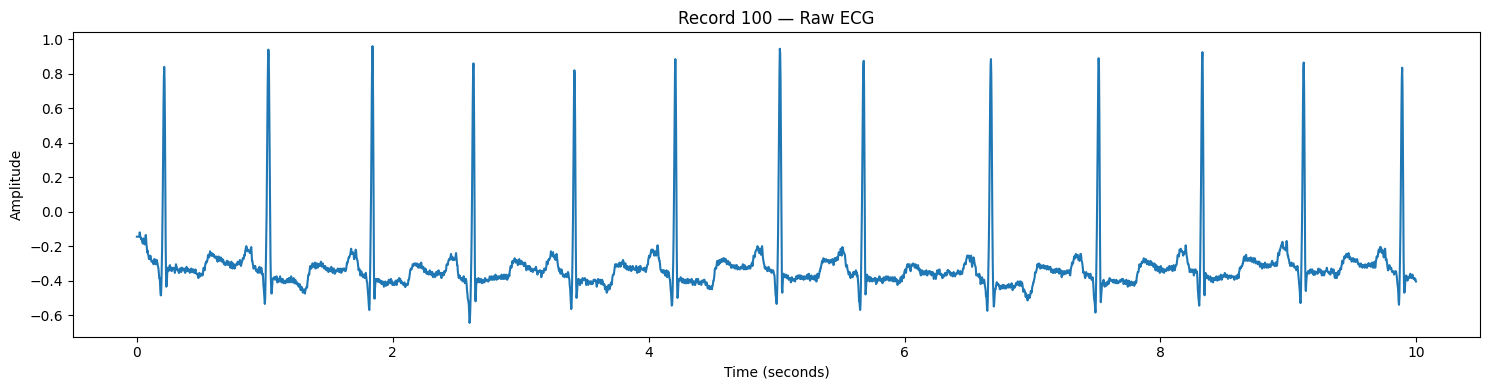

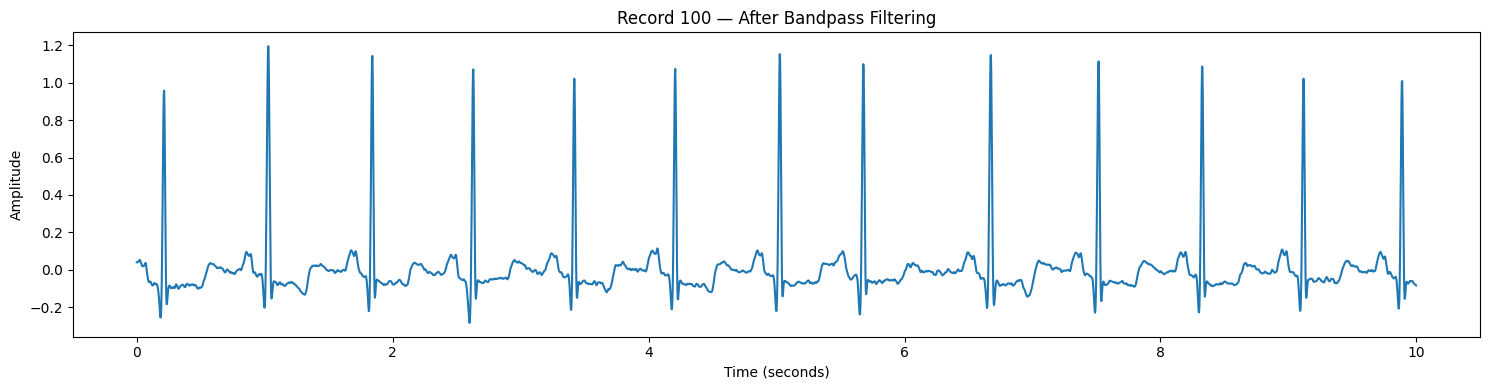

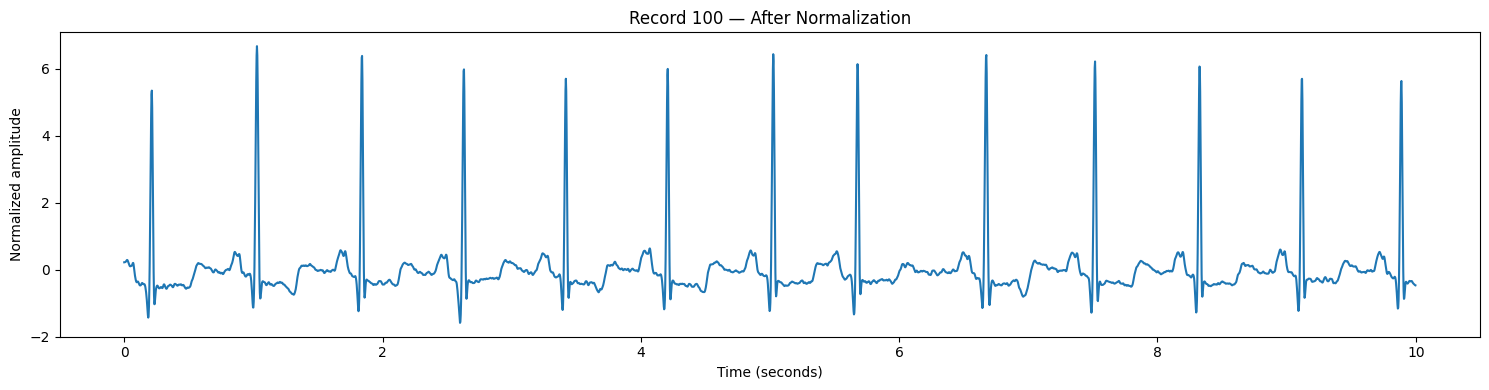

In [22]:
# ============================================================
# PHASE 2 — ECG PREPROCESSING
# ============================================================

FS = 360  # MIT-BIH sampling frequency in Hz


# ------------------------------------------------------------
# 1. Bandpass filter
# ------------------------------------------------------------

def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=FS, order=2):

    nyq = 0.5 * fs

    low = lowcut / nyq
    high = highcut / nyq

    b, a = butter(
        order,
        [low, high],
        btype='band'
    )

    return filtfilt(b, a, signal)


# ------------------------------------------------------------
# 2. Normalize ECG
# ------------------------------------------------------------

def normalize(signal):

    return (
        signal - np.mean(signal)
    ) / (
        np.std(signal) + 1e-8
    )


# ------------------------------------------------------------
# 3. Load one MIT-BIH record
# ------------------------------------------------------------

def load_record(rec_name, data_dir=DATA_DIR):

    # Load ECG signal
    record = wfdb.rdrecord(
        os.path.join(data_dir, rec_name)
    )

    # Load beat annotations
    annotation = wfdb.rdann(
        os.path.join(data_dir, rec_name),
        'atr'
    )

    # Use first ECG lead (MLII)
    signal = record.p_signal[:, 0]

    # Filtering
    filtered = bandpass_filter(signal)

    # Normalization
    filtered = normalize(filtered)

    return filtered, annotation



# ============================================================
# TEST PREPROCESSING ON RECORD 100
# ============================================================

signal_100, annotation_100 = load_record("100")

print("Record: 100")
print("Signal length:", len(signal_100))
print("Sampling frequency:", FS)
print("Duration:", round(len(signal_100) / FS / 60, 2), "minutes")
print("Number of annotations:", len(annotation_100.sample))



# ============================================================
# VISUALIZE RAW vs FILTERED ECG
# ============================================================

# Load the original record again
record_100 = wfdb.rdrecord(
    os.path.join(DATA_DIR, "100")
)

raw_signal = record_100.p_signal[:, 0]

# Apply preprocessing
filtered_signal = bandpass_filter(raw_signal)
normalized_signal = normalize(filtered_signal)


# Show first 10 seconds
seconds_to_plot = 10
samples_to_plot = seconds_to_plot * FS

time_axis = np.arange(samples_to_plot) / FS


# ------------------------------------------------------------
# Plot raw ECG
# ------------------------------------------------------------

plt.figure(figsize=(15, 4))

plt.plot(
    time_axis,
    raw_signal[:samples_to_plot]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Record 100 — Raw ECG")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot filtered ECG
# ------------------------------------------------------------

plt.figure(figsize=(15, 4))

plt.plot(
    time_axis,
    filtered_signal[:samples_to_plot]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Record 100 — After Bandpass Filtering")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot normalized ECG
# ------------------------------------------------------------

plt.figure(figsize=(15, 4))

plt.plot(
    time_axis,
    normalized_signal[:samples_to_plot]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized amplitude")
plt.title("Record 100 — After Normalization")

plt.tight_layout()
plt.show()

## 3. Beat Detection — Pan-Tompkins

In [4]:
#def pan_tompkins_detector(signal, fs=FS):
 #   diff = np.diff(signal, prepend=signal[0])
  #  squared = diff ** 2
   # window_size = int(0.15 * fs)
    #integrated = np.convolve(squared, np.ones(window_size) / window_size, mode='same')
    #threshold = np.mean(integrated) + 0.5 * np.std(integrated)
    #min_distance = int(0.2 * fs)

    #peaks = []
    #i = 1
    #while i < len(integrated) - 1:
     #   if integrated[i] > threshold and integrated[i] > integrated[i-1] and integrated[i] >= integrated[i+1]:
      #      peaks.append(i)
       ##else:
         #   i += 1
    #return np.array(peaks)

Record: 100
Signal samples: 650000
Detected peaks: 2273

First 20 detected peak positions:
[  58  353  648  928 1212 1496 1791 2031 2385 2687 2982 3264 3533 3844
 4158 4452 4738 5042 5331 5616]

First 20 peak times (seconds):
[ 0.161  0.981  1.8    2.578  3.367  4.156  4.975  5.642  6.625  7.464
  8.283  9.067  9.814 10.678 11.55  12.367 13.161 14.006 14.808 15.6  ]


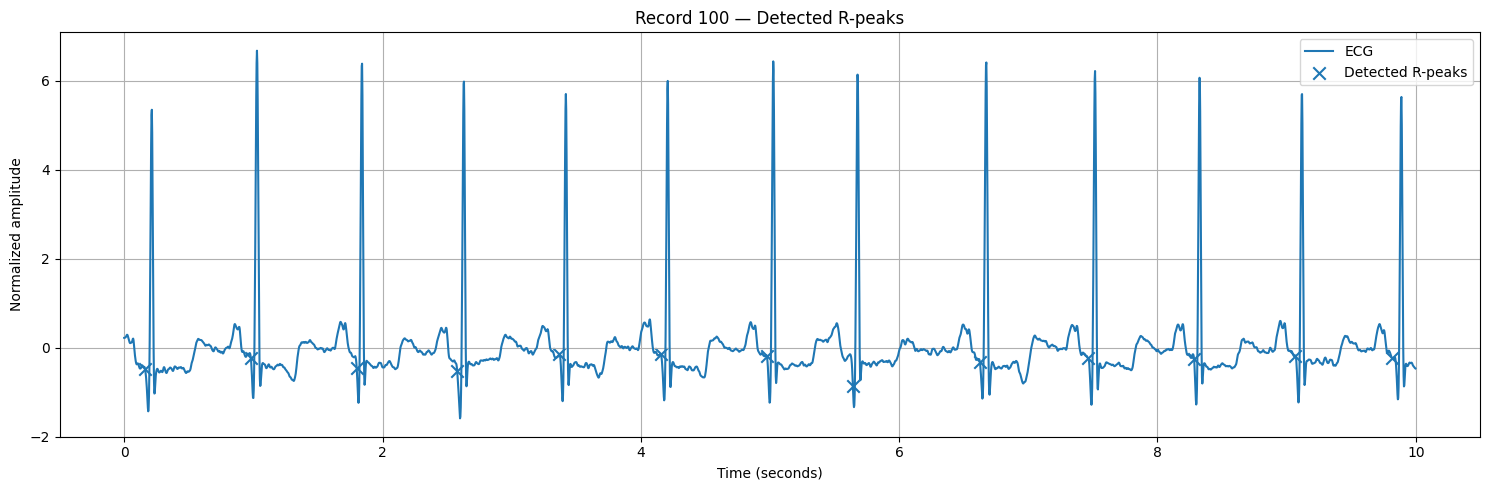

In [24]:
# ============================================================
# PHASE 3 — BEAT / R-PEAK DETECTION
# ============================================================

peaks_100 = pan_tompkins_detector(signal_100)

print("Record: 100")
print("Signal samples:", len(signal_100))
print("Detected peaks:", len(peaks_100))

print("\nFirst 20 detected peak positions:")
print(peaks_100[:20])

print("\nFirst 20 peak times (seconds):")
print(np.round(peaks_100[:20] / FS, 3))


# ============================================================
# VISUALIZE DETECTED R-PEAKS
# ============================================================

seconds_to_plot = 10
samples_to_plot = seconds_to_plot * FS

time_axis = np.arange(samples_to_plot) / FS

# Keep only detected peaks inside first 10 seconds
plot_peaks = peaks_100[
    peaks_100 < samples_to_plot
]

plt.figure(figsize=(15, 5))

plt.plot(
    time_axis,
    signal_100[:samples_to_plot],
    label="ECG"
)

plt.scatter(
    plot_peaks / FS,
    signal_100[plot_peaks],
    marker='x',
    s=80,
    label="Detected R-peaks"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized amplitude")
plt.title("Record 100 — Detected R-peaks")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# COMPARE DETECTED PEAKS WITH MIT-BIH ANNOTATIONS
# ============================================================

# MIT-BIH annotation sample positions
annotation_samples = annotation_100.sample

print("First 20 MIT-BIH annotation positions:")
print(annotation_samples[:20])

print("\nFirst 20 detected peak positions:")
print(peaks_100[:20])

# ============================================================
# CALCULATE PEAK POSITION DIFFERENCE
# ============================================================

n = min(len(peaks_100), len(annotation_samples))

differences = (
    annotation_samples[:n]
    - peaks_100[:n]
)

print("Number of compared beats:", n)

print("\nFirst 20 differences (samples):")
print(differences[:20])

print("\nMean difference:",
      round(np.mean(differences), 2),
      "samples")

print("Median difference:",
      round(np.median(differences), 2),
      "samples")

print("Mean difference in milliseconds:",
      round(np.mean(differences) / FS * 1000, 2),
      "ms")

First 20 MIT-BIH annotation positions:
[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]

First 20 detected peak positions:
[  58  353  648  928 1212 1496 1791 2031 2385 2687 2982 3264 3533 3844
 4158 4452 4738 5042 5331 5616]
Number of compared beats: 2273

First 20 differences (samples):
[ -40 -276 -278 -266 -266 -265 -276 -222 -341 -285 -276 -266 -251 -284
 -296 -282 -272 -278 -271 -270]

Mean difference: -268.81 samples
Median difference: -269.0 samples
Mean difference in milliseconds: -746.68 ms


In [28]:
symbols = annotation_100.symbol

from collections import Counter

symbol_counts = Counter(symbols)

print("Annotation symbols in Record 100:")
print(symbol_counts)


for i in range(30):
    print(
        i,
        "sample =", annotation_100.sample[i],
        "symbol =", annotation_100.symbol[i]
    )

Annotation symbols in Record 100:
Counter({'N': 2239, 'A': 33, '+': 1, 'V': 1})
0 sample = 18 symbol = +
1 sample = 77 symbol = N
2 sample = 370 symbol = N
3 sample = 662 symbol = N
4 sample = 946 symbol = N
5 sample = 1231 symbol = N
6 sample = 1515 symbol = N
7 sample = 1809 symbol = N
8 sample = 2044 symbol = A
9 sample = 2402 symbol = N
10 sample = 2706 symbol = N
11 sample = 2998 symbol = N
12 sample = 3282 symbol = N
13 sample = 3560 symbol = N
14 sample = 3862 symbol = N
15 sample = 4170 symbol = N
16 sample = 4466 symbol = N
17 sample = 4764 symbol = N
18 sample = 5060 symbol = N
19 sample = 5346 symbol = N
20 sample = 5633 symbol = N
21 sample = 5918 symbol = N
22 sample = 6214 symbol = N
23 sample = 6527 symbol = N
24 sample = 6823 symbol = N
25 sample = 7106 symbol = N
26 sample = 7391 symbol = N
27 sample = 7670 symbol = N
28 sample = 7953 symbol = N
29 sample = 8245 symbol = N


In [29]:
# ============================================================
# CORRECT DETECTED PEAK vs MIT-BIH BEAT ANNOTATION COMPARISON
# ============================================================

# Keep only actual beat annotations
beat_symbols = {'N', 'A', 'V'}

beat_mask = np.array([
    symbol in beat_symbols
    for symbol in annotation_100.symbol
])

beat_annotation_samples = annotation_100.sample[beat_mask]

print("Total annotations:", len(annotation_100.sample))
print("Beat annotations:", len(beat_annotation_samples))
print("Detected peaks:", len(peaks_100))

print("\nFirst 20 beat annotation positions:")
print(beat_annotation_samples[:20])

print("\nFirst 20 detected peak positions:")
print(peaks_100[:20])


# ============================================================
# CORRECT PEAK ALIGNMENT
# ============================================================

n = min(
    len(peaks_100),
    len(beat_annotation_samples)
)

differences = (
    beat_annotation_samples[:n]
    - peaks_100[:n]
)

print("Compared beats:", n)

print("\nFirst 20 differences:")
print(differences[:20])

print("\nMean difference:",
      round(np.mean(differences), 2),
      "samples")

print("Median difference:",
      round(np.median(differences), 2),
      "samples")

print("Mean absolute difference:",
      round(np.mean(np.abs(differences)), 2),
      "samples")

print("Mean difference:",
      round(np.mean(differences) / FS * 1000, 2),
      "ms")

print("Mean absolute difference:",
      round(np.mean(np.abs(differences)) / FS * 1000, 2),
      "ms")

Total annotations: 2274
Beat annotations: 2273
Detected peaks: 2273

First 20 beat annotation positions:
[  77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560 3862
 4170 4466 4764 5060 5346 5633]

First 20 detected peak positions:
[  58  353  648  928 1212 1496 1791 2031 2385 2687 2982 3264 3533 3844
 4158 4452 4738 5042 5331 5616]
Compared beats: 2273

First 20 differences:
[19 17 14 18 19 19 18 13 17 19 16 18 27 18 12 14 26 18 15 17]

Mean difference: 17.15 samples
Median difference: 18.0 samples
Mean absolute difference: 17.15 samples
Mean difference: 47.63 ms
Mean absolute difference: 47.65 ms


## 4. Beat Segmentation + RR-Interval Features + AAMI Labels

Each beat now becomes **two things fed to the model**:
- A **200-sample waveform window** around the R-peak (shape)
- **3 RR-interval features**: previous RR interval, next RR interval, and the ratio between them (timing/rhythm context)

This timing context is exactly what a simple shape-only CNN was missing for S-class beats.

In [31]:
'''AAMI_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    'P': 'Q', '/': 'Q', 'f': 'Q', 'Q': 'Q', 'U': 'Q'
}
CLASSES = ['N', 'S', 'V', 'F', 'Q']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
WINDOW_BEFORE, WINDOW_AFTER = 90, 110

def extract_beats_with_rr(signal, annotation, fs=FS):
    samples = annotation.sample
    symbols = annotation.symbol

    beats, rr_features, labels = [], [], []
    for idx in range(1, len(samples) - 1):  # need a beat before and after for RR features
        symbol = symbols[idx]
        if symbol not in AAMI_MAP:
            continue
        sample = samples[idx]
        start, end = sample - WINDOW_BEFORE, sample + WINDOW_AFTER
        if start < 0 or end > len(signal):
            continue

        prev_rr = (samples[idx] - samples[idx - 1]) / fs
        next_rr = (samples[idx + 1] - samples[idx]) / fs
        rr_ratio = prev_rr / next_rr if next_rr > 0 else 1.0

        beats.append(signal[start:end])
        rr_features.append([prev_rr, next_rr, rr_ratio])
        labels.append(CLASS_TO_IDX[AAMI_MAP[symbol]])

    return np.array(beats), np.array(rr_features), np.array(labels)

def build_dataset(record_names, data_dir=DATA_DIR):
    all_beats, all_rr, all_labels = [], [], []
    for rec in record_names:
        sig, ann = load_record(rec, data_dir)
        beats, rr, labels = extract_beats_with_rr(sig, ann)
        all_beats.append(beats)
        all_rr.append(rr)
        all_labels.append(labels)
    X = np.concatenate(all_beats, axis=0)
    RR = np.concatenate(all_rr, axis=0)
    y = np.concatenate(all_labels, axis=0)
    return X, RR, y

X, RR, y = build_dataset(RECORDS_TO_USE)
X = X[..., np.newaxis]
print("Waveform shape:", X.shape, "| RR features shape:", RR.shape)
print("Class distribution:", {CLASSES[k]: v for k, v in Counter(y).items()})'''

# ============================================================
# AAMI LABELING + BEAT EXTRACTION + RR FEATURES
# ============================================================

AAMI_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    'P': 'Q', '/': 'Q', 'f': 'Q', 'Q': 'Q', 'U': 'Q'
}

CLASSES = ['N', 'S', 'V', 'F', 'Q']

CLASS_TO_IDX = {
    c: i for i, c in enumerate(CLASSES)
}

# 90 samples before + 110 samples after = 200 samples
WINDOW_BEFORE = 90
WINDOW_AFTER = 110


def extract_beats_with_rr(signal, annotation, fs=FS):

    # --------------------------------------------------------
    # STEP 1: Keep ONLY beat annotations
    # --------------------------------------------------------

    beat_mask = np.array([
        symbol in AAMI_MAP
        for symbol in annotation.symbol
    ])

    # Convert to NumPy arrays before Boolean indexing
    all_samples = np.array(annotation.sample)
    all_symbols = np.array(annotation.symbol)

    # Keep only valid beat annotations
    samples = all_samples[beat_mask]
    symbols = all_symbols[beat_mask]

    beats = []
    rr_features = []
    labels = []

    # --------------------------------------------------------
    # STEP 2: Process each beat
    # --------------------------------------------------------

    for idx in range(1, len(samples) - 1):

        symbol = symbols[idx]
        sample = samples[idx]

        # ----------------------------------------------------
        # STEP 3: Extract ECG window
        # ----------------------------------------------------

        start = sample - WINDOW_BEFORE
        end = sample + WINDOW_AFTER

        if start < 0 or end > len(signal):
            continue

        beat = signal[start:end]

        if len(beat) != WINDOW_BEFORE + WINDOW_AFTER:
            continue

        # ----------------------------------------------------
        # STEP 4: Calculate RR features
        # ----------------------------------------------------

        prev_rr = (
            samples[idx] - samples[idx - 1]
        ) / fs

        next_rr = (
            samples[idx + 1] - samples[idx]
        ) / fs

        rr_ratio = (
            prev_rr / next_rr
            if next_rr > 0
            else 1.0
        )

        # ----------------------------------------------------
        # STEP 5: Store
        # ----------------------------------------------------

        beats.append(beat)

        rr_features.append([
            prev_rr,
            next_rr,
            rr_ratio
        ])

        labels.append(
            CLASS_TO_IDX[AAMI_MAP[symbol]]
        )

    return (
        np.array(beats),
        np.array(rr_features),
        np.array(labels)
    )
# ============================================================
# BUILD DATASET FROM ALL SELECTED RECORDS
# ============================================================

def build_dataset(record_names, data_dir=DATA_DIR):

    all_beats = []
    all_rr = []
    all_labels = []

    for rec in record_names:

        print(f"Processing record {rec}...")

        # Load ECG signal and annotations
        sig, ann = load_record(rec, data_dir)

        # Extract beats, RR features and labels
        beats, rr, labels = extract_beats_with_rr(
            sig,
            ann,
            fs=FS
        )

        print(
            f"  Beats: {len(beats)} | "
            f"RR features: {len(rr)} | "
            f"Labels: {len(labels)}"
        )

        all_beats.append(beats)
        all_rr.append(rr)
        all_labels.append(labels)

    # --------------------------------------------------------
    # Combine all records
    # --------------------------------------------------------

    X = np.concatenate(all_beats, axis=0)

    RR = np.concatenate(all_rr, axis=0)

    y = np.concatenate(all_labels, axis=0)

    return X, RR, y


# ============================================================
# RUN DATASET CREATION
# ============================================================

X, RR, y = build_dataset(RECORDS_TO_USE)

# Add channel dimension for 1D CNN
X = X[..., np.newaxis]


# ============================================================
# FINAL DATASET INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("DATASET CREATION COMPLETE")
print("=" * 60)

print("Waveform shape       :", X.shape)
print("RR features shape    :", RR.shape)
print("Labels shape         :", y.shape)

print("\nClass distribution:")

class_distribution = {
    CLASSES[k]: v
    for k, v in Counter(y).items()
}

print(class_distribution)

Processing record 100...
  Beats: 2271 | RR features: 2271 | Labels: 2271
Processing record 101...
  Beats: 1863 | RR features: 1863 | Labels: 1863
Processing record 102...
  Beats: 2185 | RR features: 2185 | Labels: 2185
Processing record 103...
  Beats: 2082 | RR features: 2082 | Labels: 2082
Processing record 104...
  Beats: 2227 | RR features: 2227 | Labels: 2227
Processing record 105...
  Beats: 2570 | RR features: 2570 | Labels: 2570
Processing record 106...
  Beats: 2025 | RR features: 2025 | Labels: 2025
Processing record 107...
  Beats: 2135 | RR features: 2135 | Labels: 2135
Processing record 108...
  Beats: 1761 | RR features: 1761 | Labels: 1761
Processing record 109...
  Beats: 2530 | RR features: 2530 | Labels: 2530
Processing record 111...
  Beats: 2122 | RR features: 2122 | Labels: 2122
Processing record 112...
  Beats: 2537 | RR features: 2537 | Labels: 2537
Processing record 113...
  Beats: 1793 | RR features: 1793 | Labels: 1793
Processing record 114...
  Beats: 1877

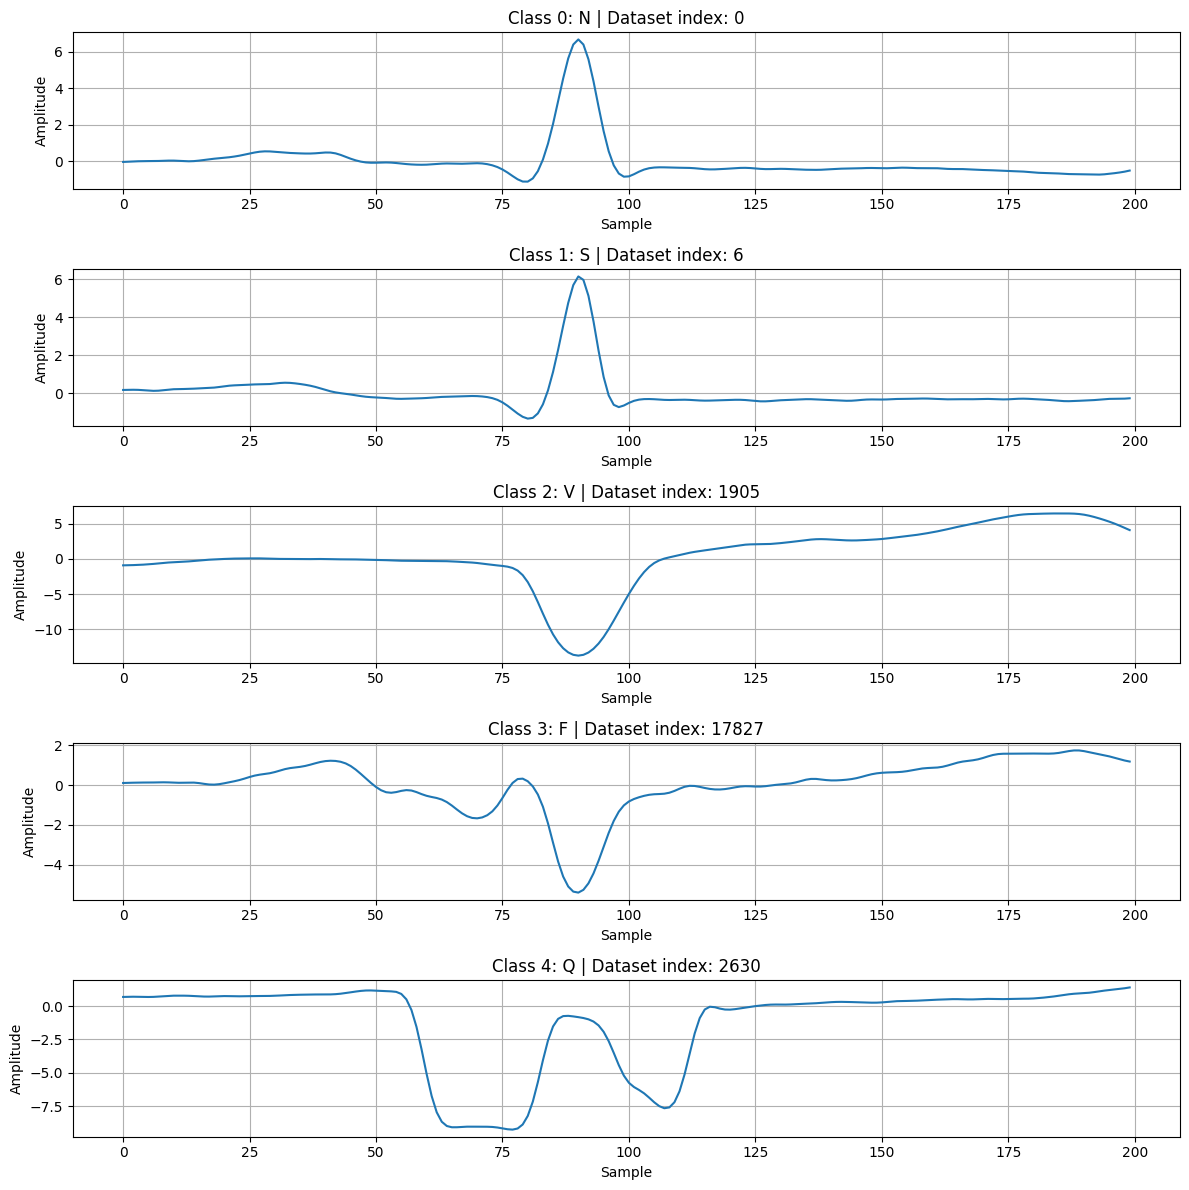

In [32]:
# ============================================================
# VISUALIZE SAMPLE ECG BEATS FROM EACH CLASS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(5, 1, figsize=(12, 12))

for class_idx, class_name in enumerate(CLASSES):

    # Find indices belonging to this class
    indices = np.where(y == class_idx)[0]

    # Take the first available beat
    sample_idx = indices[0]

    # Remove channel dimension
    beat = X[sample_idx].squeeze()

    # Plot
    axes[class_idx].plot(beat)

    axes[class_idx].set_title(
        f"Class {class_idx}: {class_name} | Dataset index: {sample_idx}"
    )

    axes[class_idx].set_xlabel("Sample")
    axes[class_idx].set_ylabel("Amplitude")
    axes[class_idx].grid(True)

plt.tight_layout()
plt.show()

## 5. Inter-Patient Train/Test Split (DS1/DS2)
Same rigorous split as before — certain patients go entirely to train, others entirely to test, so the model can't just memorize a patient's beat shape.

In [6]:
'''DS1 = ['101','106','108','109','112','114','115','116','118','119',
       '122','124','201','203','205','207','208','209','215','220',
       '223','230']
DS2 = ['100','103','105','111','113','117','121','123','200','202',
       '210','212','213','214','219','221','222','228','231','232',
       '233','234']

train_records = [r for r in RECORDS_TO_USE if r in DS1]
test_records = [r for r in RECORDS_TO_USE if r in DS2]

if len(train_records) == 0 or len(test_records) == 0:
    from sklearn.model_selection import train_test_split
    X_train, X_test, RR_train, RR_test, y_train, y_test = train_test_split(
        X, RR, y, test_size=0.2, stratify=y, random_state=42)
else:
    X_train, RR_train, y_train = build_dataset(train_records)
    X_test, RR_test, y_test = build_dataset(test_records)
    X_train, X_test = X_train[..., np.newaxis], X_test[..., np.newaxis]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train class distribution:", {CLASSES[k]: v for k, v in Counter(y_train).items()})'''

Train: (50992, 200, 1) Test: (49684, 200, 1)
Train class distribution: {'N': 45839, 'Q': 8, 'S': 943, 'V': 3788, 'F': 414}


In [33]:
# ============================================================
# 5. INTER-PATIENT TRAIN / TEST SPLIT (DS1 / DS2)
# ============================================================

DS1 = ['101','106','108','109','112','114','115','116','118','119',
       '122','124','201','203','205','207','208','209','215','220',
       '223','230']

DS2 = ['100','103','105','111','113','117','121','123','200','202',
       '210','212','213','214','219','221','222','228','231','232',
       '233','234']


# Select records belonging to DS1 and DS2
train_records = [r for r in RECORDS_TO_USE if r in DS1]
test_records  = [r for r in RECORDS_TO_USE if r in DS2]


# ------------------------------------------------------------
# Check that records were found
# ------------------------------------------------------------

print("DS1 records available:", train_records)
print("DS2 records available:", test_records)

if len(train_records) == 0:
    raise ValueError("No DS1 records found in RECORDS_TO_USE.")

if len(test_records) == 0:
    raise ValueError("No DS2 records found in RECORDS_TO_USE.")


# ------------------------------------------------------------
# Build training dataset
# ------------------------------------------------------------

X_train, RR_train, y_train = build_dataset(train_records)


# ------------------------------------------------------------
# Build testing dataset
# ------------------------------------------------------------

X_test, RR_test, y_test = build_dataset(test_records)


# ------------------------------------------------------------
# Add CNN channel dimension
# Shape:
# (samples, 200) → (samples, 200, 1)
# ------------------------------------------------------------

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]


# ------------------------------------------------------------
# Display dataset information
# ------------------------------------------------------------

print("\n================ DATASET SPLIT ================")

print("Train records:", len(train_records))
print("Test records :", len(test_records))

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nTrain class distribution:")
print({
    CLASSES[k]: v
    for k, v in sorted(Counter(y_train).items())
})

print("\nTest class distribution:")
print({
    CLASSES[k]: v
    for k, v in sorted(Counter(y_test).items())
})

DS1 records available: ['101', '106', '108', '109', '112', '114', '115', '116', '118', '119', '122', '124', '201', '203', '205', '207', '208', '209', '215', '220', '223', '230']
DS2 records available: ['100', '103', '105', '111', '113', '117', '121', '123', '200', '202', '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']
Processing record 101...
  Beats: 1863 | RR features: 1863 | Labels: 1863
Processing record 106...
  Beats: 2025 | RR features: 2025 | Labels: 2025
Processing record 108...
  Beats: 1761 | RR features: 1761 | Labels: 1761
Processing record 109...
  Beats: 2530 | RR features: 2530 | Labels: 2530
Processing record 112...
  Beats: 2537 | RR features: 2537 | Labels: 2537
Processing record 114...
  Beats: 1877 | RR features: 1877 | Labels: 1877
Processing record 115...
  Beats: 1951 | RR features: 1951 | Labels: 1951
Processing record 116...
  Beats: 2410 | RR features: 2410 | Labels: 2410
Processing record 118...
  Beats: 2276 | RR features

## 6. Oversample Minority Classes (Train Set Only)
We duplicate S/V/F/Q beats — with small random jitter/noise added to the waveform so duplicates aren't exact copies — until every class has a reasonable share of the training set. **Never oversample the test set** — that would fake your evaluation.

In [7]:
'''def oversample(X, RR, y, target_ratio=0.5, seed=42):
    """Oversample each minority class up to target_ratio * majority_class_count."""
    rng = np.random.default_rng(seed)
    counts = Counter(y)
    majority_count = max(counts.values())
    target_count = int(majority_count * target_ratio)

    X_out, RR_out, y_out = [X], [RR], [y]
    for cls, count in counts.items():
        if count >= target_count:
            continue
        n_needed = target_count - count
        cls_idx = np.where(y == cls)[0]
        chosen = rng.choice(cls_idx, size=n_needed, replace=True)

        waveform_noise = rng.normal(0, 0.02, size=(n_needed,) + X.shape[1:])
        rr_noise = rng.normal(0, 0.01, size=(n_needed,) + RR.shape[1:])

        X_out.append(X[chosen] + waveform_noise)
        RR_out.append(RR[chosen] + rr_noise)
        y_out.append(y[chosen])

    X_final = np.concatenate(X_out, axis=0)
    RR_final = np.concatenate(RR_out, axis=0)
    y_final = np.concatenate(y_out, axis=0)

    shuffle_idx = rng.permutation(len(y_final))
    return X_final[shuffle_idx], RR_final[shuffle_idx], y_final[shuffle_idx]

X_train_os, RR_train_os, y_train_os = oversample(X_train, RR_train, y_train, target_ratio=0.5)
print("After oversampling:", {CLASSES[k]: v for k, v in Counter(y_train_os).items()})'''

After oversampling: {'N': 45839, 'V': 22919, 'S': 22919, 'F': 22919, 'Q': 22919}


In [34]:
# ============================================================
# 6. OVERSAMPLING OF MINORITY CLASSES
# ============================================================

def oversample(X, RR, y, target_ratio=0.2, max_multiplier=10, seed=42):
    """
    Oversample minority classes in the TRAINING SET only.

    target_ratio:
        Desired class size relative to the majority class.

    max_multiplier:
        Prevent extremely rare classes from being generated
        thousands of times from only a few original samples.
    """

    rng = np.random.default_rng(seed)

    counts = Counter(y)
    majority_count = max(counts.values())

    # Desired target based on majority class
    ratio_target = int(majority_count * target_ratio)

    X_out = [X]
    RR_out = [RR]
    y_out = [y]

    print("Original class distribution:")
    print({
        CLASSES[k]: v
        for k, v in sorted(counts.items())
    })

    print("\nOversampling targets:")

    for cls in sorted(counts.keys()):

        count = counts[cls]

        # Maximum allowed based on original class size
        capped_target = count * max_multiplier

        # Final target
        target_count = min(ratio_target, capped_target)

        if count >= target_count:
            print(f"{CLASSES[cls]}: {count} → {count} (no oversampling)")
            continue

        n_needed = target_count - count

        cls_idx = np.where(y == cls)[0]

        chosen = rng.choice(
            cls_idx,
            size=n_needed,
            replace=True
        )

        # Small waveform noise
        waveform_noise = rng.normal(
            0,
            0.02,
            size=(n_needed,) + X.shape[1:]
        )

        # Small RR-feature noise
        rr_noise = rng.normal(
            0,
            0.01,
            size=(n_needed,) + RR.shape[1:]
        )

        X_out.append(
            X[chosen] + waveform_noise
        )

        RR_out.append(
            RR[chosen] + rr_noise
        )

        y_out.append(
            y[chosen]
        )

        print(
            f"{CLASSES[cls]}: "
            f"{count} → {target_count} "
            f"(added {n_needed})"
        )

    # Combine
    X_final = np.concatenate(X_out, axis=0)
    RR_final = np.concatenate(RR_out, axis=0)
    y_final = np.concatenate(y_out, axis=0)

    # Shuffle
    shuffle_idx = rng.permutation(len(y_final))

    X_final = X_final[shuffle_idx]
    RR_final = RR_final[shuffle_idx]
    y_final = y_final[shuffle_idx]

    return X_final, RR_final, y_final


# ============================================================
# APPLY ONLY TO TRAINING DATA
# ============================================================

X_train_os, RR_train_os, y_train_os = oversample(
    X_train,
    RR_train,
    y_train,
    target_ratio=0.2,
    max_multiplier=10,
    seed=42
)


# ============================================================
# FINAL DISTRIBUTION
# ============================================================

print("\n================ AFTER OVERSAMPLING ================")

print({
    CLASSES[k]: v
    for k, v in sorted(Counter(y_train_os).items())
})

print("\nOriginal training shape:")
print(X_train.shape)

print("\nOversampled training shape:")
print(X_train_os.shape)

print("\nTesting shape:")
print(X_test.shape)

Original class distribution:
{'N': 45824, 'S': 943, 'V': 3788, 'F': 414, 'Q': 8}

Oversampling targets:
N: 45824 → 45824 (no oversampling)
S: 943 → 9164 (added 8221)
V: 3788 → 9164 (added 5376)
F: 414 → 4140 (added 3726)
Q: 8 → 80 (added 72)

================ AFTER OVERSAMPLING ================
{'N': 45824, 'S': 9164, 'V': 9164, 'F': 4140, 'Q': 80}

Original training shape:
(50977, 200, 1)

Oversampled training shape:
(68372, 200, 1)

Testing shape:
(49668, 200, 1)


## 7. Model — Two-Branch CNN (Waveform + RR Features)
Branch A processes the beat shape (CNN). Branch B processes the 3 RR-interval numbers (dense). They're concatenated before the final classification layer — so the model can use both **what the beat looks like** and **how the heart's rhythm is behaving around it**.

In [8]:
'''import tensorflow as tf
from tensorflow.keras import layers, models, Model

def build_model(waveform_shape=(200, 1), rr_shape=(3,), n_classes=5):
    # Branch A: waveform (CNN)
    wave_input = layers.Input(shape=waveform_shape, name='waveform')
    x = layers.Conv1D(16, 7, activation='relu', padding='same')(wave_input)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(32, 5, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Branch B: RR-interval features (dense)
    rr_input = layers.Input(shape=rr_shape, name='rr_features')
    r = layers.Dense(16, activation='relu')(rr_input)
    r = layers.Dense(16, activation='relu')(r)

    combined = layers.Concatenate()([x, r])
    d = layers.Dense(32, activation='relu')(combined)
    d = layers.Dropout(0.3)(d)
    output = layers.Dense(n_classes, activation='softmax')(d)

    return Model(inputs=[wave_input, rr_input], outputs=output)

model = build_model()
model.summary()'''

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ waveform            │ (None, 200, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 200, 16)   │        128 │ waveform[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 200, 16)   │         64 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 100, 16)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 100, 32)   │      2,592 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 50, 32)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 50, 64)    │      6,208 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rr_features         │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         64 │ rr_features[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        272 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,592 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │        165 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,469 (48.71 KB)

 Trainable params: 12,245 (47.83 KB)

 Non-trainable params: 224 (896.00 B)

In [36]:
# ============================================================
# 7. BUILD 1D CNN MODEL
# ============================================================

import tensorflow as tf
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    GlobalAveragePooling1D,
    Dense
)
from tensorflow.keras.optimizers import Adam


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

tf.random.set_seed(42)
np.random.seed(42)


# ------------------------------------------------------------
# Number of classes
# ------------------------------------------------------------

NUM_CLASSES = len(CLASSES)

print("Number of classes:", NUM_CLASSES)
print("Classes:", CLASSES)


# ------------------------------------------------------------
# CNN Architecture
# ------------------------------------------------------------

cnn_model = Sequential([

    # Input
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    # ========================================================
    # Convolution Block 1
    # ========================================================

    Conv1D(
        filters=32,
        kernel_size=7,
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    Dropout(0.20),


    # ========================================================
    # Convolution Block 2
    # ========================================================

    Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    Dropout(0.25),


    # ========================================================
    # Convolution Block 3
    # ========================================================

    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    Dropout(0.30),


    # ========================================================
    # Feature Extraction
    # ========================================================

    GlobalAveragePooling1D(),


    # ========================================================
    # Fully Connected Layer
    # ========================================================

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.40),


    # ========================================================
    # Output Layer
    # ========================================================

    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

cnn_model.summary()

Number of classes: 5
Classes: ['N', 'S', 'V', 'F', 'Q']


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 200, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 200, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 200, 32)        │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 200, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 100, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 100, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 50, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,205 (278.14 KB)

 Trainable params: 70,565 (275.64 KB)

 Non-trainable params: 640 (2.50 KB)

In [38]:
# ============================================================
# 8. CREATE TRAINING / VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train_base, X_val, RR_train_base, RR_val, y_train_base, y_val = train_test_split(
    X_train,
    RR_train,
    y_train,
    test_size=0.10,
    stratify=y_train,
    random_state=42
)

print("Training before oversampling:", X_train_base.shape)
print("Validation:", X_val.shape)

print("\nTraining class distribution:")
print({
    CLASSES[k]: v
    for k, v in sorted(Counter(y_train_base).items())
})

print("\nValidation class distribution:")
print({
    CLASSES[k]: v
    for k, v in sorted(Counter(y_val).items())
})


# ============================================================
# 9. OVERSAMPLE TRAINING DATA ONLY
# ============================================================

X_train_os, RR_train_os, y_train_os = oversample(
    X_train_base,
    RR_train_base,
    y_train_base,
    target_ratio=0.2,
    max_multiplier=10,
    seed=42
)

print("\n================ FINAL TRAINING DATA ================")

print("Training shape after oversampling:")
print(X_train_os.shape)

print("\nTraining class distribution:")
print({
    CLASSES[k]: v
    for k, v in sorted(Counter(y_train_os).items())
})

print("\nValidation shape:")
print(X_val.shape)

print("\nValidation class distribution:")
print({
    CLASSES[k]: v
    for k, v in sorted(Counter(y_val).items())
})

print("\nTest shape:")
print(X_test.shape)

print("\nTest class distribution:")
print({
    CLASSES[k]: v
    for k, v in sorted(Counter(y_test).items())
})

Training before oversampling: (45879, 200, 1)
Validation: (5098, 200, 1)

Training class distribution:
{'N': 41241, 'S': 849, 'V': 3409, 'F': 373, 'Q': 7}

Validation class distribution:
{'N': 4583, 'S': 94, 'V': 379, 'F': 41, 'Q': 1}
Original class distribution:
{'N': 41241, 'S': 849, 'V': 3409, 'F': 373, 'Q': 7}

Oversampling targets:
N: 41241 → 41241 (no oversampling)
S: 849 → 8248 (added 7399)
V: 3409 → 8248 (added 4839)
F: 373 → 3730 (added 3357)
Q: 7 → 70 (added 63)

================ FINAL TRAINING DATA ================
Training shape after oversampling:
(61537, 200, 1)

Training class distribution:
{'N': 41241, 'S': 8248, 'V': 8248, 'F': 3730, 'Q': 70}

Validation shape:
(5098, 200, 1)

Validation class distribution:
{'N': 4583, 'S': 94, 'V': 379, 'F': 41, 'Q': 1}

Test shape:
(49668, 200, 1)

Test class distribution:
{'N': 44218, 'S': 1836, 'V': 3219, 'F': 388, 'Q': 7}


In [ ]:
# ============================================================
# 10. TRAIN 1D CNN
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)


# ------------------------------------------------------------
# Reduce learning rate when validation loss stops improving
# ------------------------------------------------------------

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

history = cnn_model.fit(
    X_train_os,
    y_train_os,

    validation_data=(X_val, y_val),

    epochs=50,
    batch_size=128,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 105s 198ms/step - accuracy: 0.9248 - loss: 0.2448 - val_accuracy: 0.9561 - val_loss: 0.1711 - learning_rate: 0.0010
Epoch 2/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 139s 193ms/step - accuracy: 0.9668 - loss: 0.1200 - val_accuracy: 0.9798 - val_loss: 0.0788 - learning_rate: 0.0010
Epoch 3/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 90s 187ms/step - accuracy: 0.9725 - loss: 0.0982 - val_accuracy: 0.9802 - val_loss: 0.0739 - learning_rate: 0.0010
Epoch 4/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 90s 186ms/step - accuracy: 0.9762 - loss: 0.0837 - val_accuracy: 0.9812 - val_loss: 0.0731 - learning_rate: 0.0010
Epoch 5/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 89s 185ms/step - accuracy: 0.9788 - loss: 0.0749 - val_accuracy: 0.9831 - val_loss: 0.0667 - learning_rate: 0.0010
Epoch 6/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 94s 195ms/step - accuracy: 0.9802 - loss: 0.0681 - val_accuracy: 0.9878 - val_loss: 0.0535 - learning_rate: 0.0010
Epoch 7/50
481/481 ━━━━━━━━━━━━━━━━━━━━ 88s 184ms/step - accuracy: 0

## 8. Focal Loss
Standard cross-entropy treats every mistake equally. Focal loss down-weights easy/majority examples (correctly-classified N beats) and focuses gradient on hard/rare examples (S, F) — this is the standard fix for severe class imbalance like MIT-BIH's.

In [9]:
def sparse_categorical_focal_loss(gamma=2.0, alpha=None):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])

        ce = -y_true_one_hot * tf.math.log(y_pred)
        weight = tf.pow(1 - y_pred, gamma)
        fl = weight * ce

        if alpha is not None:
            alpha_tensor = tf.constant(alpha, dtype=tf.float32)
            fl = fl * alpha_tensor

        return tf.reduce_sum(fl, axis=-1)
    return loss_fn

# Give extra weight to rare classes (S, F, Q) inside the focal loss itself
class_counts = Counter(y_train_os)
total = sum(class_counts.values())
alpha = [total / (len(CLASSES) * class_counts.get(i, 1)) for i in range(len(CLASSES))]
alpha = [a / max(alpha) for a in alpha]  # normalize to max 1.0
print("Focal loss alpha per class:", dict(zip(CLASSES, [round(a, 3) for a in alpha])))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=sparse_categorical_focal_loss(gamma=2.0, alpha=alpha),
    metrics=['accuracy']
)

Focal loss alpha per class: {'N': 0.5, 'S': 1.0, 'V': 1.0, 'F': 1.0, 'Q': 1.0}


In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
]

history = model.fit(
    {'waveform': X_train_os, 'rr_features': RR_train_os}, y_train_os,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    callbacks=callbacks
)

Epoch 1/10
967/967 ━━━━━━━━━━━━━━━━━━━━ 50s 48ms/step - accuracy: 0.9155 - loss: 0.1010 - val_accuracy: 0.9769 - val_loss: 0.0303 - learning_rate: 0.0010
Epoch 2/10
967/967 ━━━━━━━━━━━━━━━━━━━━ 45s 47ms/step - accuracy: 0.9740 - loss: 0.0290 - val_accuracy: 0.8698 - val_loss: 0.0800 - learning_rate: 0.0010
Epoch 3/10
967/967 ━━━━━━━━━━━━━━━━━━━━ 83s 48ms/step - accuracy: 0.9808 - loss: 0.0199 - val_accuracy: 0.9891 - val_loss: 0.0113 - learning_rate: 0.0010
Epoch 4/10
967/967 ━━━━━━━━━━━━━━━━━━━━ 45s 47ms/step - accuracy: 0.9841 - loss: 0.0154 - val_accuracy: 0.9889 - val_loss: 0.0114 - learning_rate: 0.0010
Epoch 5/10
967/967 ━━━━━━━━━━━━━━━━━━━━ 48s 49ms/step - accuracy: 0.9870 - loss: 0.0122 - val_accuracy: 0.9439 - val_loss: 0.0408 - learning_rate: 0.0010
Epoch 6/10
967/967 ━━━━━━━━━━━━━━━━━━━━ 45s 47ms/step - accuracy: 0.9882 - loss: 0.0108 - val_accuracy: 0.9904 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 7/10
967/967 ━━━━━━━━━━━━━━━━━━━━ 47s 48ms/step - accuracy: 0.9885 - l

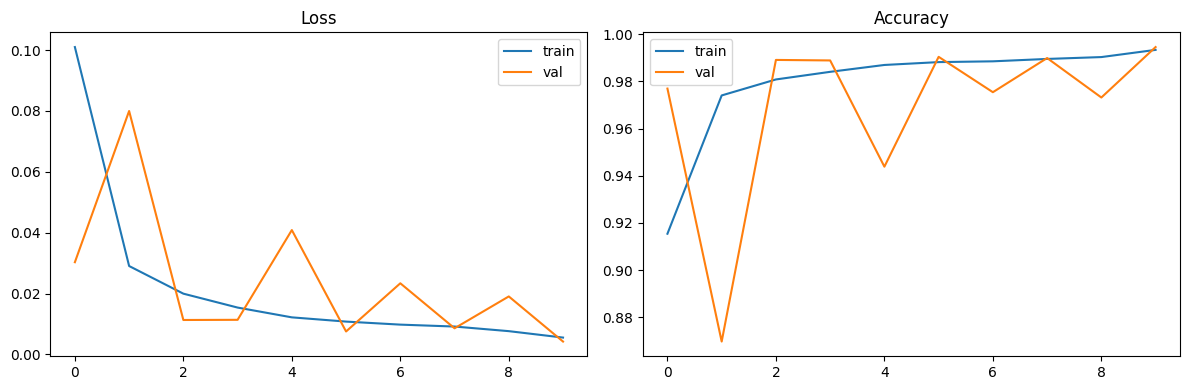

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.tight_layout()
plt.show()

## 9. Evaluation — on the untouched (non-oversampled) test set

1553/1553 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step
              precision    recall  f1-score   support

           N     0.9574    0.9779    0.9675     44233
           S     0.3134    0.1057    0.1580      1836
           V     0.8528    0.9283    0.8889      3220
           F     0.0106    0.0103    0.0104       388
           Q     0.0000    0.0000    0.0000         7

    accuracy                         0.9347     49684
   macro avg     0.4268    0.4044    0.4050     49684
weighted avg     0.9193    0.9347    0.9249     49684

N: sensitivity=0.9779  specificity=0.6469
S: sensitivity=0.1057  specificity=0.9911
V: sensitivity=0.9283  specificity=0.9889
F: sensitivity=0.0103  specificity=0.9924
Q: sensitivity=0.0000  specificity=1.0000


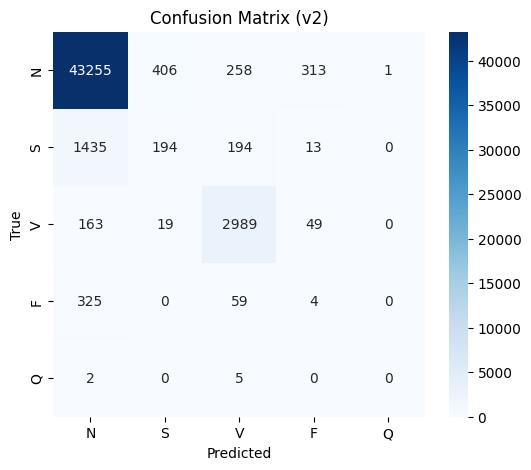


False alarms per minute: 1.482
Macro-F1: 0.4050


In [12]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = model.predict({'waveform': X_test, 'rr_features': RR_test})
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=CLASSES, digits=4))

cm = confusion_matrix(y_test, y_pred)

def per_class_sensitivity_specificity(cm):
    n_classes = cm.shape[0]
    results = {}
    total = cm.sum()
    for i in range(n_classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - TP - FN - FP
        sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        results[CLASSES[i]] = {'sensitivity': sens, 'specificity': spec}
    return results

metrics = per_class_sensitivity_specificity(cm)
for cls, vals in metrics.items():
    print(f"{cls}: sensitivity={vals['sensitivity']:.4f}  specificity={vals['specificity']:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix (v2)')
plt.show()

normal_idx = CLASS_TO_IDX['N']
false_alarms = np.sum((y_pred != normal_idx) & (y_test == normal_idx))
total_minutes = len(test_records) * 30 if 'test_records' in dir() and test_records else (len(y_test) / FS) / 60
print(f"\nFalse alarms per minute: {false_alarms / total_minutes:.3f}")

macro_f1 = classification_report(y_test, y_pred, target_names=CLASSES, output_dict=True)['macro avg']['f1-score']
print(f"Macro-F1: {macro_f1:.4f}")

## 10. Binary View — Normal vs Abnormal
Since the practical ask is *"predict whether a heartbeat is normal or abnormal"*, here's that simplified, clinically-relevant view collapsed from the 5-class output.

              precision    recall  f1-score   support

      Normal     0.9574    0.9779    0.9675     44233
    Abnormal     0.7829    0.6469    0.7084      5451

    accuracy                         0.9416     49684
   macro avg     0.8701    0.8124    0.8380     49684
weighted avg     0.9382    0.9416    0.9391     49684



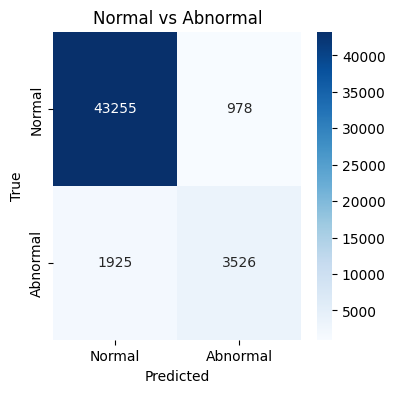

In [13]:
y_test_binary = (y_test != CLASS_TO_IDX['N']).astype(int)     # 0=Normal, 1=Abnormal
y_pred_binary = (y_pred != CLASS_TO_IDX['N']).astype(int)

print(classification_report(y_test_binary, y_pred_binary, target_names=['Normal', 'Abnormal'], digits=4))

cm_bin = confusion_matrix(y_test_binary, y_pred_binary)
plt.figure(figsize=(4, 4))
sns.heatmap(cm_bin, annot=True, fmt='d', xticklabels=['Normal','Abnormal'],
            yticklabels=['Normal','Abnormal'], cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Normal vs Abnormal')
plt.show()

## 11. Ready-to-Use Inference Function
This is the practical deliverable: **give it any record name, and it detects every beat, classifies each one, plots the result, and prints a percentage breakdown for every beat type (N, S, V, F, Q).** Works on any MIT-BIH record (or your own signal in the same format — see the notes below).

Record: 111
Total beats detected: 2123

Beat type   Count     Percentage  
----------------------------------
N           2036      95.9%
S           0         0.0%
V           21        0.99%
F           66        3.11%
Q           0         0.0%
----------------------------------
Abnormal    87        4.1%


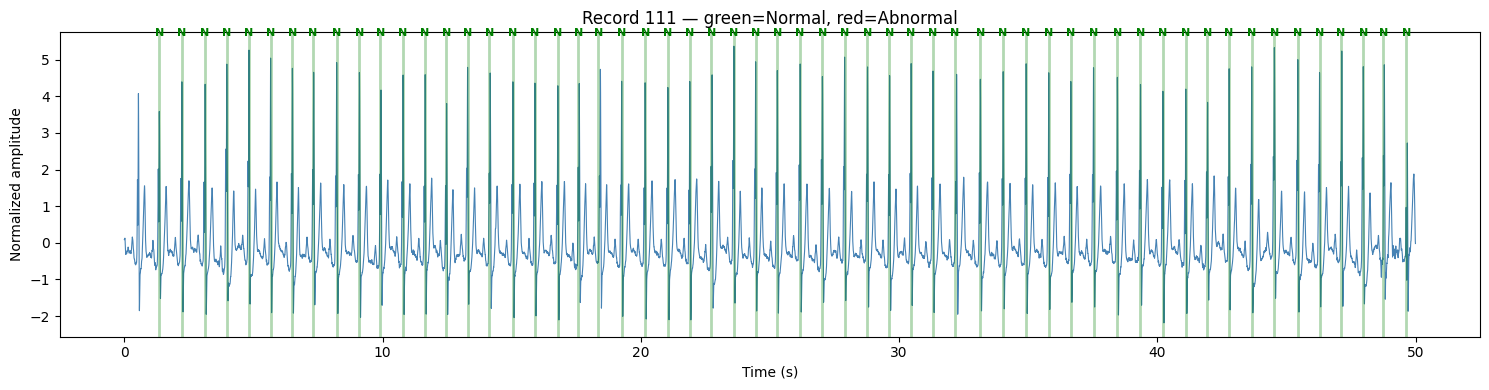

In [14]:
def predict_record(record_name, data_dir=DATA_DIR, plot_seconds=10, plot_start_sec=0):
    """
    Full end-to-end pipeline for ONE record:
      1. Load + preprocess the signal
      2. Detect beats with Pan-Tompkins
      3. Compute RR-interval features per detected beat
      4. Classify each beat (5-class + binary Normal/Abnormal)
      5. Plot a segment of the ECG with predictions
      6. Return a summary

    If the record isn't downloaded yet, it will be fetched from PhysioNet automatically.
    """
    if not os.path.exists(os.path.join(data_dir, record_name + ".dat")):
        wfdb.dl_database('mitdb', dl_dir=data_dir, records=[record_name])

    signal, _ = load_record(record_name, data_dir)
    peaks = pan_tompkins_detector(signal)

    beats, rr_feats, valid_peaks = [], [], []
    for i in range(1, len(peaks) - 1):
        p = peaks[i]
        start, end = p - WINDOW_BEFORE, p + WINDOW_AFTER
        if start < 0 or end > len(signal):
            continue
        prev_rr = (peaks[i] - peaks[i - 1]) / FS
        next_rr = (peaks[i + 1] - peaks[i]) / FS
        rr_ratio = prev_rr / next_rr if next_rr > 0 else 1.0

        beats.append(signal[start:end])
        rr_feats.append([prev_rr, next_rr, rr_ratio])
        valid_peaks.append(p)

    if len(beats) == 0:
        print("No valid beats detected.")
        return None

    beats = np.array(beats)[..., np.newaxis]
    rr_feats = np.array(rr_feats)

    probs = model.predict({'waveform': beats, 'rr_features': rr_feats}, verbose=0)
    pred_classes = np.argmax(probs, axis=1)
    pred_labels = [CLASSES[c] for c in pred_classes]
    is_abnormal = pred_classes != CLASS_TO_IDX['N']

    # --- Summary ---
    total_beats = len(valid_peaks)
    class_counts = Counter(pred_labels)
    # Percentage for every beat type, including classes with zero detections
    class_percentages = {
        cls: round(100 * class_counts.get(cls, 0) / total_beats, 2)
        for cls in CLASSES
    }
    summary = {
        'record': record_name,
        'total_beats_detected': total_beats,
        'class_counts': {cls: class_counts.get(cls, 0) for cls in CLASSES},
        'class_percentages': class_percentages,
        'abnormal_beat_count': int(is_abnormal.sum()),
        'abnormal_beat_pct': round(100 * is_abnormal.mean(), 2),
        'peak_samples': valid_peaks,
        'predicted_labels': pred_labels,
    }

    print(f"Record: {record_name}")
    print(f"Total beats detected: {summary['total_beats_detected']}\n")
    print(f"{'Beat type':<12}{'Count':<10}{'Percentage':<12}")
    print("-" * 34)
    for cls in CLASSES:
        count = summary['class_counts'][cls]
        pct = summary['class_percentages'][cls]
        print(f"{cls:<12}{count:<10}{pct}%")
    print("-" * 34)
    print(f"{'Abnormal':<12}{summary['abnormal_beat_count']:<10}{summary['abnormal_beat_pct']}%")

    # --- Plot a segment ---
    start_sample = int(plot_start_sec * FS)
    end_sample = int((plot_start_sec + plot_seconds) * FS)
    segment = signal[start_sample:end_sample]
    time_axis = np.arange(len(segment)) / FS

    plt.figure(figsize=(15, 4))
    plt.plot(time_axis, segment, color='steelblue', linewidth=0.8)
    for p, lbl in zip(valid_peaks, pred_labels):
        if start_sample <= p < end_sample:
            rel_t = (p - start_sample) / FS
            color = 'green' if lbl == 'N' else 'red'
            plt.axvline(rel_t, color=color, alpha=0.3, linewidth=2)
            plt.text(rel_t, max(segment) * 1.05, lbl, ha='center', color=color,
                      fontsize=8, fontweight='bold')
    plt.xlabel('Time (s)'); plt.ylabel('Normalized amplitude')
    plt.title(f'Record {record_name} — green=Normal, red=Abnormal')
    plt.tight_layout()
    plt.show()

    return summary

# --- Example usage: run on any record ---
summary = predict_record('111', plot_seconds=50, plot_start_sec=0)

**Notes on using this with your own / new data (not just MIT-BIH):**
- Your signal must be a single-lead ECG sampled at **360 Hz** (or resample to 360 Hz first) — the beat window sizes and RR features are tuned to this.
- Pass a raw 1D numpy array through `bandpass_filter()` + `normalize()` first, then reuse the beat-detection + prediction logic inside `predict_record` (skip the `wfdb` loading part, which is MIT-BIH-specific).

## 12. Edge Deployment — Export the Two-Input Model to TFLite
Same as before, but the model now takes two inputs (waveform + RR features), which TFLite handles natively.

In [15]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('ecg_model_v2.tflite', 'wb') as f:
    f.write(tflite_model)

size_kb = os.path.getsize('ecg_model_v2.tflite') / 1024
print(f"TFLite model size: {size_kb:.1f} KB")

# Verify predictions match
interpreter = tf.lite.Interpreter(model_path='ecg_model_v2.tflite')
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# input_details order may vary; match by name
for detail in input_details:
    if 'waveform' in detail['name']:
        wave_idx = detail['index']
    else:
        rr_idx = detail['index']

interpreter.set_tensor(wave_idx, X_test[0:1].astype(np.float32))
interpreter.set_tensor(rr_idx, RR_test[0:1].astype(np.float32))
interpreter.invoke()
tflite_pred = interpreter.get_tensor(output_details[0]['index'])

keras_pred = model.predict({'waveform': X_test[0:1], 'rr_features': RR_test[0:1]}, verbose=0)
print("Keras prediction:", np.argmax(keras_pred), "| TFLite prediction:", np.argmax(tflite_pred))

Saved artifact at '/tmp/tmpgspr5qzc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 200, 1), dtype=tf.float32, name='waveform'), TensorSpec(shape=(None, 3), dtype=tf.float32, name='rr_features')]
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  137992032576784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137992032577744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137992032577168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137992032577552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137992032576592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137992032577360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137992032578320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137992032576016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137992032578128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137992032579088: Ten

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 13. Summary
- **Practical output**: `predict_record(record_name)` — the ready-to-use function for "give it any record, tell me the heartbeat types."
- **Fixes applied vs. v1**: RR-interval timing features, oversampling, focal loss — all specifically targeting the S/F recall problem.
- **Two views available**: full 5-class (N/S/V/F/Q) and simplified binary (Normal/Abnormal) — use whichever matches how you want to present results.
- **Deployment-ready**: `ecg_model_v2.tflite` is a quantized, two-input model exportable to a mobile/edge app.

**Compare your new classification report to the v1 one you already have** — S and F recall should be meaningfully higher now. If they're still weak, the next lever to pull is increasing `target_ratio` in the oversampling step (e.g., 0.5 → 0.8) or `gamma` in the focal loss (2.0 → 3.0) to push even harder on the rare classes.